# Predicting Electricity Consumption and Detecting Anomalous Energy Use

This notebook develops a simple machine-learning workflow for university-building electricity data.

We will work mainly with the **GEPIII / ASHRAE Energy Prediction** dataset.

The notebook has two main phases:

**Phase 1 — Electricity prediction**
- Clean and prepare the data
- Explore electricity consumption
- Create simple time, building and weather features
- Build a **Linear Regression base model**
- Build **Random Forest** and **Gradient Boosting proposed models**
- Compare the models using MAE, RMSE and R²

**Phase 2 — Anomaly detection**
- Calculate prediction residuals
- Identify unusually large residuals
- Rank unusual observations by their prediction error

The official GEPIII test set is kept separate because its actual electricity readings are not provided.

## 1. Import libraries

We use common Python libraries and keep the code simple so each step is easy to follow.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Load the GEPIII data

Put the six GEPIII files in the same folder as this notebook before running it.

In [2]:
train = pd.read_csv("../ashrae-energy-prediction/train.csv")
test = pd.read_csv("../ashrae-energy-prediction/test.csv")
building_metadata = pd.read_csv("../ashrae-energy-prediction/building_metadata.csv")
weather_train = pd.read_csv("../ashrae-energy-prediction/weather_train.csv")
weather_test = pd.read_csv("../ashrae-energy-prediction/weather_test.csv")
sample_submission = pd.read_csv("../ashrae-energy-prediction/sample_submission.csv")

## 3. Structure of all the data

In [3]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Building metadata shape:", building_metadata.shape)
print("Weather train shape:", weather_train.shape)
print("Weather test shape:", weather_test.shape)

Train shape: (20216100, 4)
Test shape: (41697600, 4)
Building metadata shape: (1449, 6)
Weather train shape: (139773, 9)
Weather test shape: (277243, 9)


In [4]:
print(train.head())
print(train.columns)

print(building_metadata.head())
print(weather_train.head())

   building_id  meter            timestamp  meter_reading
0            0      0  2016-01-01 00:00:00            0.0
1            1      0  2016-01-01 00:00:00            0.0
2            2      0  2016-01-01 00:00:00            0.0
3            3      0  2016-01-01 00:00:00            0.0
4            4      0  2016-01-01 00:00:00            0.0
Index(['building_id', 'meter', 'timestamp', 'meter_reading'], dtype='str')
   site_id  building_id primary_use  square_feet  year_built  floor_count
0        0            0   Education         7432      2008.0          NaN
1        0            1   Education         2720      2004.0          NaN
2        0            2   Education         5376      1991.0          NaN
3        0            3   Education        23685      2002.0          NaN
4        0            4   Education       116607      1975.0          NaN
   site_id            timestamp  air_temperature  cloud_coverage  \
0        0  2016-01-01 00:00:00             25.0             6.0 

## 4. Select electricity data

GEPIII contains several meter types. Meter `0` represents electricity so we select that for our project

In [5]:
electricity = train[train["meter"] == 0].copy()

print("Electricity data shape:", electricity.shape)
print(electricity.head())

Electricity data shape: (12060910, 4)
   building_id  meter            timestamp  meter_reading
0            0      0  2016-01-01 00:00:00            0.0
1            1      0  2016-01-01 00:00:00            0.0
2            2      0  2016-01-01 00:00:00            0.0
3            3      0  2016-01-01 00:00:00            0.0
4            4      0  2016-01-01 00:00:00            0.0


## 5. Convert timestamps

In [6]:
electricity["timestamp"] = pd.to_datetime(electricity["timestamp"])

weather_train["timestamp"] = pd.to_datetime(weather_train["timestamp"])
weather_test["timestamp"] = pd.to_datetime(weather_test["timestamp"])

test["timestamp"] = pd.to_datetime(test["timestamp"])

## 6. Data cleaning

In [7]:
# Check exact duplicate rows
print("Exact duplicate rows:", electricity.duplicated().sum())

# Check duplicate building/timestamp/meter records
print("Duplicate building-timestamp-meter rows:", electricity.duplicated( subset=["building_id", "timestamp", "meter"]).sum())

# Check negative readings
print("Negative meter readings:", (electricity["meter_reading"] < 0).sum())

# Check missing target readings
print("Missing meter readings:", electricity["meter_reading"].isna().sum())

Exact duplicate rows: 0
Duplicate building-timestamp-meter rows: 0
Negative meter readings: 0
Missing meter readings: 0


### 6.1 Remove duplicate records

In [8]:
before = len(electricity)

# Remove exact duplicates
electricity = electricity.drop_duplicates().copy()

# Remove duplicate building/timestamp/meter observations
electricity = electricity.drop_duplicates(subset=["building_id", "timestamp", "meter"],keep="first").copy()

print("Rows removed because of duplicates:", before - len(electricity))
print("Rows remaining:", len(electricity))

Rows removed because of duplicates: 0
Rows remaining: 12060910


### 6.2 Handle invalid negative readings

In [9]:
before = len(electricity)

electricity = electricity[electricity["meter_reading"] >= 0].copy()

print("Negative readings removed:", before - len(electricity))
print("Rows remaining:", len(electricity))

Negative readings removed: 0
Rows remaining: 12060910


### 6.3 Handle missing target readings

In [10]:
before = len(electricity)

electricity = electricity.dropna(subset=["meter_reading"]).copy()

print("Rows removed because target was missing:", before - len(electricity))
print("Missing target values remaining:", electricity["meter_reading"].isna().sum())

Rows removed because target was missing: 0
Missing target values remaining: 0


## 7. Create basic time features

Electricity use can change depending on the hour, day of the week, month and whether it is a weekend.

In [11]:
electricity["hour"] = electricity["timestamp"].dt.hour
electricity["dayofweek"] = electricity["timestamp"].dt.dayofweek
electricity["month"] = electricity["timestamp"].dt.month
electricity["weekend"] = (electricity["dayofweek"] >= 5).astype(int)

## 8. Exploratory data analysis

These plots help us understand the electricity data before modelling.

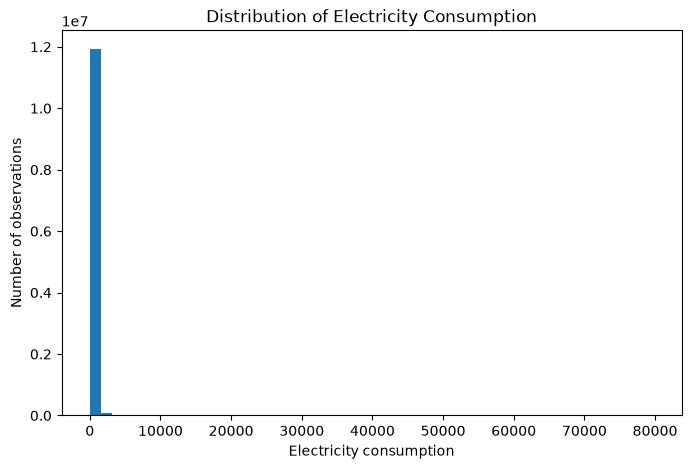

In [12]:
plt.figure(figsize=(8, 5))
plt.hist(electricity["meter_reading"], bins=50)
plt.xlabel("Electricity consumption")
plt.ylabel("Number of observations")
plt.title("Distribution of Electricity Consumption")
plt.show()

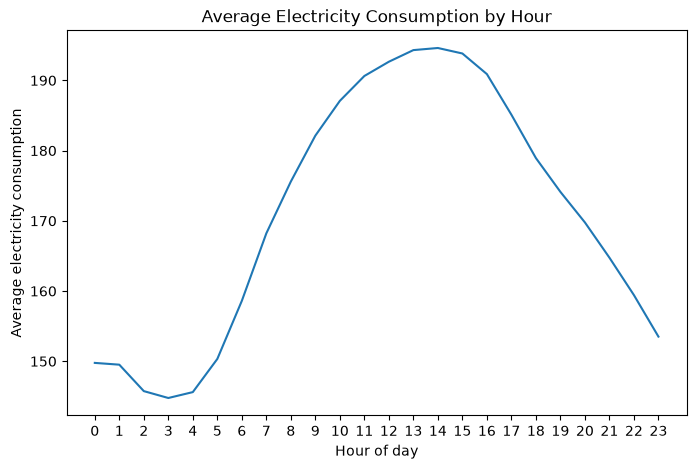

In [13]:
hourly_average = electricity.groupby("hour")["meter_reading"].mean()

plt.figure(figsize=(8, 5))
plt.plot(hourly_average.index, hourly_average.values)
plt.xlabel("Hour of day")
plt.ylabel("Average electricity consumption")
plt.title("Average Electricity Consumption by Hour")
plt.xticks(range(24))
plt.show()

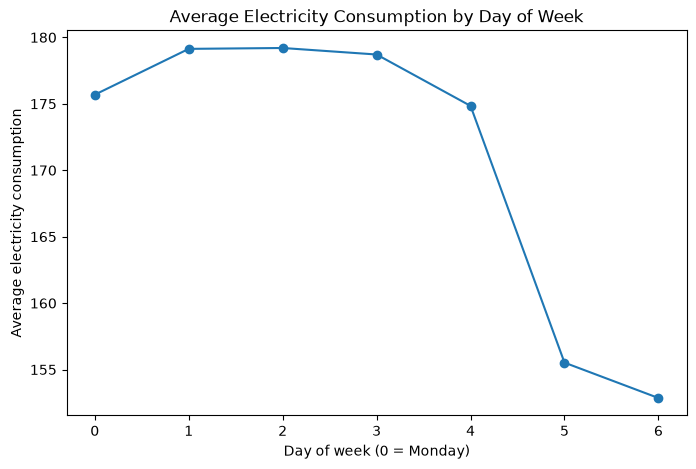

In [20]:
weekday_average = electricity.groupby("dayofweek")["meter_reading"].mean()

plt.figure(figsize=(8, 5))
plt.plot(weekday_average.index, weekday_average.values, marker="o")
plt.xlabel("Day of week (0 = Monday)")
plt.ylabel("Average electricity consumption")
plt.title("Average Electricity Consumption by Day of Week")
plt.show()

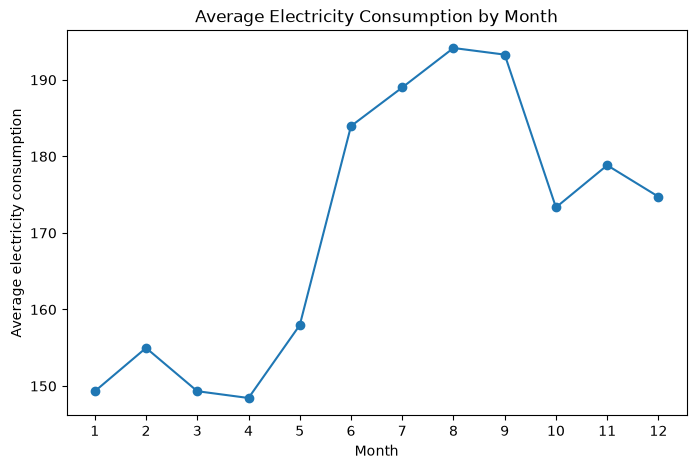

In [14]:
monthly_average = electricity.groupby("month")["meter_reading"].mean()

plt.figure(figsize=(8, 5))
plt.plot(monthly_average.index, monthly_average.values, marker="o")
plt.xlabel("Month")
plt.ylabel("Average electricity consumption")
plt.title("Average Electricity Consumption by Month")
plt.xticks(range(1, 13))
plt.show()

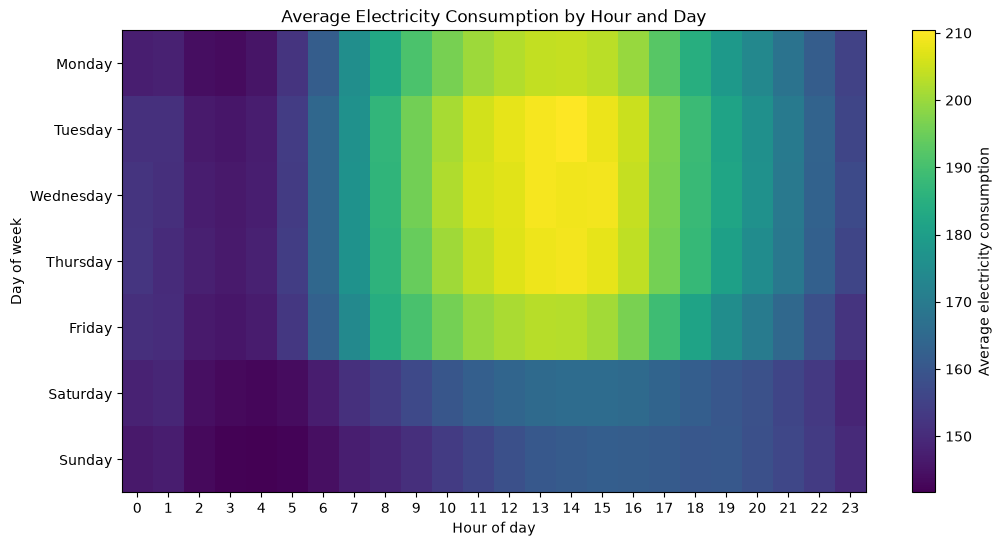

In [22]:
# Average electricity consumption by hour and day of week

heatmap_data = electricity.pivot_table(values="meter_reading", index="dayofweek", columns="hour", aggfunc="mean")
# Rename the days for easier reading
heatmap_data.index = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
plt.figure(figsize=(12, 6))
plt.imshow(heatmap_data, aspect="auto")
plt.colorbar(label="Average electricity consumption")
plt.xlabel("Hour of day")
plt.ylabel("Day of week")
plt.title("Average Electricity Consumption by Hour and Day")
plt.xticks(range(24))
plt.yticks(range(7), heatmap_data.index)
plt.show()

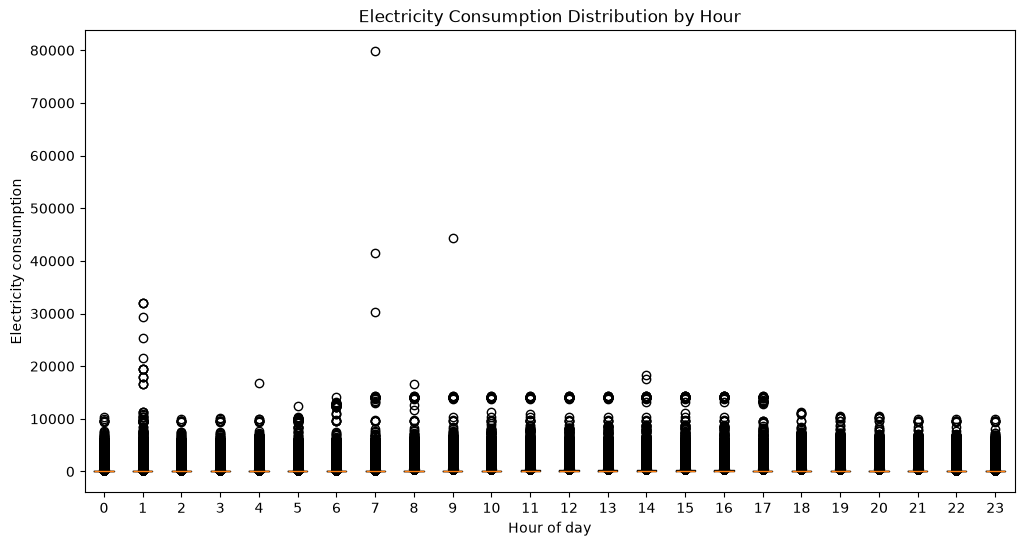

In [15]:
# Electricity consumption distribution by hour

hourly_data = []

for hour in range(24):
    values = electricity[electricity["hour"] == hour]["meter_reading"]
    hourly_data.append(values)

plt.figure(figsize=(12, 6))
plt.boxplot(hourly_data)
plt.xlabel("Hour of day")
plt.ylabel("Electricity consumption")
plt.title("Electricity Consumption Distribution by Hour")
plt.xticks(range(1, 25), range(24))
plt.show()

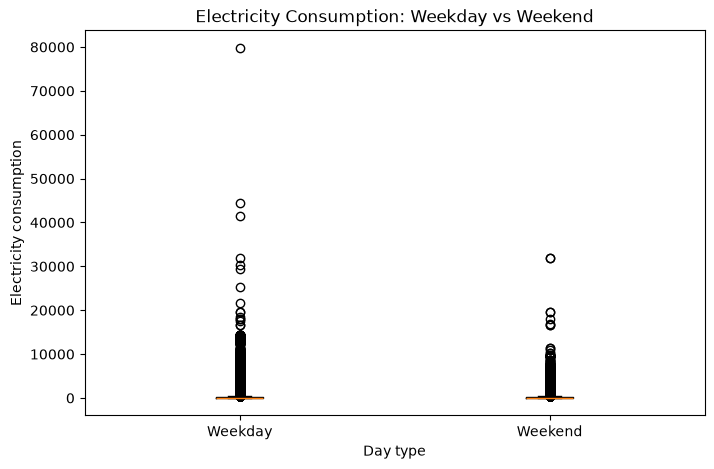

In [16]:
# Compare weekday and weekend electricity consumption

weekday_data = electricity[electricity["weekend"] == 0]["meter_reading"]
weekend_data = electricity[electricity["weekend"] == 1]["meter_reading"]
plt.figure(figsize=(8, 5))
plt.boxplot([weekday_data, weekend_data],tick_labels=["Weekday", "Weekend"])
plt.xlabel("Day type")
plt.ylabel("Electricity consumption")
plt.title("Electricity Consumption: Weekday vs Weekend")
plt.show()

## 9. Merge building and weather information

In [17]:
data = electricity.merge(building_metadata, on="building_id", how="left")

data = data.merge(weather_train, on=["site_id", "timestamp"], how="left")

print("Merged data shape:", data.shape)

Merged data shape: (12060910, 20)


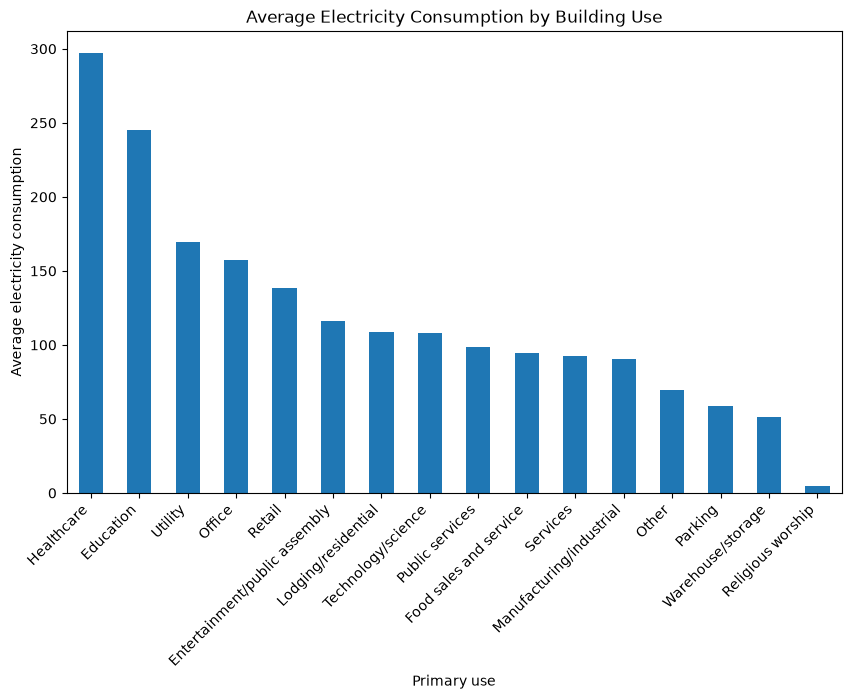

In [18]:
# Average electricity consumption by building type

building_type_average = (data.groupby("primary_use")["meter_reading"].mean().sort_values(ascending=False))
plt.figure(figsize=(10, 6))
building_type_average.plot(kind="bar")
plt.xlabel("Primary use")
plt.ylabel("Average electricity consumption")
plt.title("Average Electricity Consumption by Building Use")
plt.xticks(rotation=45, ha="right")
plt.show()

## 10. Check missing values after merging

In [19]:
missing = data.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

floor_count           9096083
year_built            6470035
cloud_coverage        5329652
precip_depth_1_hr     2513679
sea_level_pressure    1018383
wind_direction         678715
wind_speed              66795
dew_temperature         49091
air_temperature         47325
dtype: int64


## 11. Handle missing feature values

In [20]:
features = ["hour", "dayofweek", "month", "weekend", "air_temperature", "square_feet"]

# Check that the selected features exist
print("Features:", features)

# Show missing values before filling
print("Missing values before filling:")
print(data[features].isna().sum())

Features: ['hour', 'dayofweek', 'month', 'weekend', 'air_temperature', 'square_feet']
Missing values before filling:
hour                   0
dayofweek              0
month                  0
weekend                0
air_temperature    47325
square_feet            0
dtype: int64


In [21]:
# Fill missing numerical features with their median
for column in features:
    median_value = data[column].median()
    data[column] = data[column].fillna(median_value)

print("Missing values after filling:")
print(data[features].isna().sum())

Missing values after filling:
hour               0
dayofweek          0
month              0
weekend            0
air_temperature    0
square_feet        0
dtype: int64


### 11.1 Final data-quality check

In [22]:
print("Missing target:", data["meter_reading"].isna().sum())
print("Negative target values:", (data["meter_reading"] < 0).sum())

print("Duplicate building-timestamp-meter rows:", data.duplicated(subset=["building_id", "timestamp", "meter"]).sum())

print("Final modelling rows:", len(data))

Missing target: 0
Negative target values: 0
Duplicate building-timestamp-meter rows: 0
Final modelling rows: 12060910


## 12. Sort the data by time

In [23]:
data = data.sort_values("timestamp").reset_index(drop=True)

## 13. Train/validation split

We need labelled data to evaluate our models.

The official GEPIII `test.csv` does not contain the actual `meter_reading`, so we cannot use it to calculate MAE, RMSE or R².

Instead, we temporarily hold out the **last 20% of the labelled data** as a validation period.

This is preferable to a random split because a random split can mix future observations into the training data.

In [24]:
split_index = int(len(data) * 0.80)

train_data = data.iloc[:split_index].copy()
valid_data = data.iloc[split_index:].copy()

print("Training rows:", len(train_data))
print("Validation rows:", len(valid_data))

print("Training period:", train_data["timestamp"].min(), "to", train_data["timestamp"].max())
print("Validation period:", valid_data["timestamp"].min(), "to", valid_data["timestamp"].max())

Training rows: 9648728
Validation rows: 2412182
Training period: 2016-01-01 00:00:00 to 2016-10-20 07:00:00
Validation period: 2016-10-20 07:00:00 to 2016-12-31 23:00:00


## 14. Prepare model inputs

We use the same six simple features for all three models so that the comparison is fair.

The missing-value medians are calculated from the training period only and then applied to both training and validation data.

In [25]:
X_train = train_data[features].copy()
X_valid = valid_data[features].copy()

y_train = train_data["meter_reading"]
y_valid = valid_data["meter_reading"]

# Calculate medians only from the training data
train_medians = X_train.median()

for column in features:
    X_train[column] = X_train[column].fillna(train_medians[column])
    X_valid[column] = X_valid[column].fillna(train_medians[column])

print("Missing values in X_train:")
print(X_train.isna().sum())

print("Missing values in X_valid:")
print(X_valid.isna().sum())

Missing values in X_train:
hour               0
dayofweek          0
month              0
weekend            0
air_temperature    0
square_feet        0
dtype: int64
Missing values in X_valid:
hour               0
dayofweek          0
month              0
weekend            0
air_temperature    0
square_feet        0
dtype: int64


# 15. Build the models

### Base model: Linear Regression

### Proposed model 1: Random Forest

### Proposed model 2: Gradient Boosting

In [34]:
# 1. Base Model: Linear Regression
base_model = LinearRegression()
base_model.fit(X_train, y_train)

base_pred = base_model.predict(X_valid)


# 2. Proposed Model: Random Forest
rf_model = RandomForestRegressor(n_estimators=50, max_depth=12, min_samples_leaf=5, random_state=42, n_jobs=2)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_valid)


# 3. Proposed Model: Gradient Boosting
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_valid)

## 16. Compare the three models

In [26]:
model_predictions = {"Linear Regression (Base)": base_pred, "Random Forest (Proposed)": rf_pred, "Gradient Boosting (Proposed)": gb_pred}

results = []

for model_name, predictions in model_predictions.items():
    mae = mean_absolute_error(y_valid, predictions)
    rmse = np.sqrt(mean_squared_error(y_valid, predictions))
    r2 = r2_score(y_valid, predictions)

    results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results)

print(results_df.to_string(index=False))

NameError: name 'base_pred' is not defined

### 16.1 Visual comparison

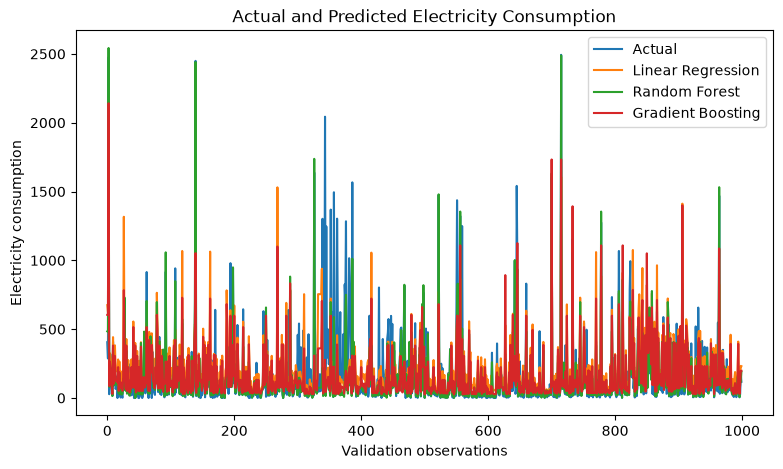

In [36]:
plt.figure(figsize=(9, 5))

sample_size = min(1000, len(y_valid))
sample_index = np.arange(sample_size)

plt.plot(sample_index, y_valid.iloc[:sample_size].values, label="Actual")
plt.plot(sample_index, base_pred[:sample_size], label="Linear Regression")
plt.plot(sample_index, rf_pred[:sample_size], label="Random Forest")
plt.plot(sample_index, gb_pred[:sample_size], label="Gradient Boosting")

plt.xlabel("Validation observations")
plt.ylabel("Electricity consumption")
plt.title("Actual and Predicted Electricity Consumption")
plt.legend()
plt.show()

## 17. Select a proposed model for residual analysis

In [37]:
rf_rmse = np.sqrt(mean_squared_error(y_valid, rf_pred))
gb_rmse = np.sqrt(mean_squared_error(y_valid, gb_pred))

if rf_rmse <= gb_rmse:
    chosen_model_name = "Random Forest"
    chosen_predictions = rf_pred
else:
    chosen_model_name = "Gradient Boosting"
    chosen_predictions = gb_pred

print("Model used for residual analysis:", chosen_model_name)

Model used for residual analysis: Random Forest


## 18. Calculate prediction residuals

In [38]:
validation_results = valid_data[
    ["timestamp", "building_id", "site_id", "meter_reading"]
].copy()

validation_results["predicted"] = chosen_predictions
validation_results["residual"] = (
    validation_results["meter_reading"]
    - validation_results["predicted"]
)

validation_results["absolute_error"] = (
    validation_results["residual"].abs()
)

validation_results.head()

,timestamp,building_id,site_id,meter_reading,predicted,residual,absolute_error
9648728,2016-10-20 07:00:00,1099,13,405.431,484.109434,-78.678434,78.678434
9648729,2016-10-20 07:00:00,1090,13,287.132,480.414888,-193.282888,193.282888
9648730,2016-10-20 07:00:00,1088,13,2475.600,2542.983706,-67.383706,67.383706
9648731,2016-10-20 07:00:00,1087,13,27.577,80.637122,-53.060122,53.060122
9648732,2016-10-20 07:00:00,1086,13,182.384,214.502210,-32.118210,32.118210


## 19. Simple residual-based anomaly detection

In [39]:
residual_mean = validation_results["residual"].mean()
residual_std = validation_results["residual"].std()

upper_threshold = residual_mean + 3 * residual_std
lower_threshold = residual_mean - 3 * residual_std

validation_results["anomaly"] = (
    (validation_results["residual"] > upper_threshold) |
    (validation_results["residual"] < lower_threshold)
)

print("Number of flagged anomalies:", validation_results["anomaly"].sum())
print("Percentage flagged:", validation_results["anomaly"].mean() * 100)

Number of flagged anomalies: 24491
Percentage flagged: 1.0153048153082977


## 20. Rank the most unusual observations

In [40]:
top_anomalies = validation_results.sort_values(
    "absolute_error",
    ascending=False
).head(20)

top_anomalies

,timestamp,building_id,site_id,meter_reading,predicted,residual,absolute_error,anomaly
12028786,2016-12-31 01:00:00,993,9,17999.0,1794.968108,16204.031892,16204.031892,True
11995099,2016-12-30 01:00:00,993,9,17999.0,1798.336861,16200.663139,16200.663139,True
11961428,2016-12-29 01:00:00,993,9,17999.0,1798.336861,16200.663139,16200.663139,True
10124772,2016-11-03 14:00:00,799,7,17502.1,4128.465070,13373.634930,13373.634930,True
11177353,2016-12-05 15:00:00,799,7,14397.7,3462.559574,10935.140426,10935.140426,True
11681329,2016-12-20 17:00:00,799,7,14184.3,3292.450427,10891.849573,10891.849573,True
10786539,2016-11-23 11:00:00,799,7,14188.0,3462.559574,10725.440426,10725.440426,True
11679925,2016-12-20 16:00:00,799,7,14184.3,3462.559574,10721.740426,10721.740426,True
11982534,2016-12-29 16:00:00,799,7,14106.1,3462.559574,10643.540426,10643.540426,True
11402544,2016-12-12 10:00:00,799,7,13926.6,3462.559574,10464.040426,10464.040426,True


## 21. Inspect the residuals

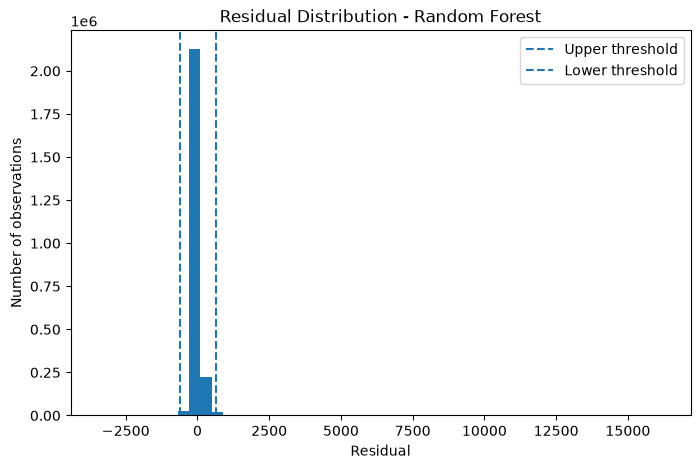

In [41]:
plt.figure(figsize=(8, 5))
plt.hist(validation_results["residual"], bins=50)
plt.axvline(upper_threshold, linestyle="--", label="Upper threshold")
plt.axvline(lower_threshold, linestyle="--", label="Lower threshold")
plt.xlabel("Residual")
plt.ylabel("Number of observations")
plt.title(f"Residual Distribution - {chosen_model_name}")
plt.legend()
plt.show()

## 22. Historical feature engineering

The next step improves the model by adding lag-based historical features. Electricity demand is strongly time dependent, so including the previous hour, the same hour from the previous day, and the same hour from the previous week helps the model understand recurring demand patterns.

### Why these lag features?

- Previous hour: captures short-term demand changes.
- Previous day at the same hour: captures daily recurring demand cycles.
- Previous week at the same hour: captures weekly seasonal patterns.

These lag variables are useful because building electricity use is often highly time-dependent and repetitive.

In [27]:
#  Historical Feature Engineering

# Make a copy so we don't accidentally modify the original dataframe
elec_df = electricity.copy()

# Sort by building and time
elec_df = elec_df.sort_values(
    ["building_id", "timestamp"]
).reset_index(drop=True)

# Check the result
elec_df[["building_id", "timestamp", "meter_reading"]].head(10)

,building_id,timestamp,meter_reading
0,0,2016-01-01 00:00:00,0.0
1,0,2016-01-01 01:00:00,0.0
2,0,2016-01-01 02:00:00,0.0
3,0,2016-01-01 03:00:00,0.0
4,0,2016-01-01 04:00:00,0.0
5,0,2016-01-01 05:00:00,0.0
6,0,2016-01-01 06:00:00,0.0
7,0,2016-01-01 07:00:00,0.0
8,0,2016-01-01 08:00:00,0.0
9,0,2016-01-01 09:00:00,0.0


In [ ]:
# Add lag-based past electricity usage to model recent and recurring building behavior
# Previous hour
elec_df["lag_1h"] = (
    elec_df.groupby("building_id")["meter_reading"]
    .shift(1)
)

# Same hour on the previous day
elec_df["lag_24h"] = (
    elec_df.groupby("building_id")["meter_reading"]
    .shift(24)
)

# Same hour on the previous week
elec_df["lag_168h"] = (
    elec_df.groupby("building_id")["meter_reading"]
    .shift(168)
)

# shift - historical information

In [29]:
elec_df[
    [
        "building_id",
        "timestamp",
        "meter_reading",
        "lag_1h",
        "lag_24h",
        "lag_168h"
    ]
].head(200)

,building_id,timestamp,meter_reading,lag_1h,lag_24h,lag_168h
0,0,2016-01-01 00:00:00,0.0,NaN,NaN,NaN
1,0,2016-01-01 01:00:00,0.0,0.0,NaN,NaN
2,0,2016-01-01 02:00:00,0.0,0.0,NaN,NaN
3,0,2016-01-01 03:00:00,0.0,0.0,NaN,NaN
4,0,2016-01-01 04:00:00,0.0,0.0,NaN,NaN
...,...,...,...,...,...,...
195,0,2016-01-09 03:00:00,0.0,0.0,0.0,0.0
196,0,2016-01-09 04:00:00,0.0,0.0,0.0,0.0
197,0,2016-01-09 05:00:00,0.0,0.0,0.0,0.0
198,0,2016-01-09 06:00:00,0.0,0.0,0.0,0.0


In [30]:
elec_df[
    ["lag_1h", "lag_24h", "lag_168h"]
].isna().sum()

lag_1h        1413
lag_24h      33912
lag_168h    237384
dtype: int64

In [ ]:
# Calculate time differences within each building to confirm the data is hourly consistent
# This helps validate that the lag variables align with the expected temporal structure
time_diff = (
    elec_df
    .groupby("building_id")["timestamp"]
    .diff()
)

time_diff.value_counts().head(10)

timestamp
0 days 01:00:00    12050549
0 days 02:00:00        5360
0 days 03:00:00         763
1 days 01:00:00         643
0 days 04:00:00         456
0 days 05:00:00         208
1 days 00:00:00         178
2 days 01:00:00         172
0 days 06:00:00         140
5 days 02:00:00         114
Name: count, dtype: int64

In [32]:
time_diff.describe()

count                  12059497
mean     0 days 01:01:18.130124
std      0 days 04:22:15.971442
min             0 days 01:00:00
25%             0 days 01:00:00
50%             0 days 01:00:00
75%             0 days 01:00:00
max           168 days 00:00:00
Name: timestamp, dtype: object

In [33]:
(time_diff == pd.Timedelta(hours=1)).mean()

np.float64(0.9991409437596334)

In [34]:
elec_df["hour"] = elec_df["timestamp"].dt.hour
elec_df["dayofweek"] = elec_df["timestamp"].dt.dayofweek
elec_df["month"] = elec_df["timestamp"].dt.month
elec_df["weekend"] = (
    elec_df["dayofweek"] >= 5
).astype(int)

In [35]:
current_features = [
    "hour",
    "dayofweek",
    "month",
    "weekend",
    "air_temperature",
    "square_feet"
]

In [36]:
historical_features = [
    "hour",
    "dayofweek",
    "month",
    "weekend",
    "air_temperature",
    "square_feet",
    "lag_1h",
    "lag_24h",
    "lag_168h"
]

In [37]:
time_diff.value_counts().head(10)

timestamp
0 days 01:00:00    12050549
0 days 02:00:00        5360
0 days 03:00:00         763
1 days 01:00:00         643
0 days 04:00:00         456
0 days 05:00:00         208
1 days 00:00:00         178
2 days 01:00:00         172
0 days 06:00:00         140
5 days 02:00:00         114
Name: count, dtype: int64

In [38]:
(time_diff == pd.Timedelta(hours=1)).mean()

np.float64(0.9991409437596334)

In [39]:
# Count consecutive observations that are NOT exactly 1 hour apart
non_hourly = time_diff[
    time_diff != pd.Timedelta(hours=1)
].dropna()

print("Number of non-hourly gaps:", len(non_hourly))
print("Percentage of non-hourly gaps:", len(non_hourly) / len(time_diff.dropna()) * 100)

Number of non-hourly gaps: 8948
Percentage of non-hourly gaps: 0.07419878291772866


In [40]:
# Show the most common unusual gaps
print(non_hourly.value_counts().head(20))

timestamp
0 days 02:00:00     5360
0 days 03:00:00      763
1 days 01:00:00      643
0 days 04:00:00      456
0 days 05:00:00      208
1 days 00:00:00      178
2 days 01:00:00      172
0 days 06:00:00      140
5 days 02:00:00      114
48 days 13:00:00     113
0 days 07:00:00      106
0 days 08:00:00      104
0 days 09:00:00       75
5 days 01:00:00       69
0 days 10:00:00       60
0 days 11:00:00       35
2 days 00:00:00       27
23 days 01:00:00      26
0 days 12:00:00       25
0 days 15:00:00       14
Name: count, dtype: int64


In [41]:
# Show the largest gaps
print(non_hourly.sort_values(ascending=False).head(20))

460344     168 days 00:00:00
254765     108 days 21:00:00
8564834    106 days 21:00:00
8558696    106 days 20:00:00
5219351     95 days 18:00:00
8614572     85 days 13:00:00
5405874     81 days 07:00:00
5398504     65 days 17:00:00
4087499     52 days 12:00:00
11580576    48 days 13:00:00
11625364    48 days 13:00:00
11617893    48 days 13:00:00
11610446    48 days 13:00:00
11602988    48 days 13:00:00
11595516    48 days 13:00:00
11588044    48 days 13:00:00
11550708    48 days 13:00:00
11573110    48 days 13:00:00
11565641    48 days 13:00:00
11558176    48 days 13:00:00
Name: timestamp, dtype: timedelta64[us]


In [42]:
elec_lag_df = elec_df.dropna(
    subset=["lag_1h", "lag_24h", "lag_168h"]
).copy()

print("Original rows:", len(elec_df))
print("Rows after lag removal:", len(elec_lag_df))
print("Rows removed:", len(elec_df) - len(elec_lag_df))

Original rows: 12060910
Rows after lag removal: 11823526
Rows removed: 237384


In [43]:
elec_lag_df[
    elec_lag_df["building_id"] == 0
][
    [
        "building_id",
        "timestamp",
        "meter_reading",
        "lag_1h",
        "lag_24h",
        "lag_168h"
    ]
].head(20)

,building_id,timestamp,meter_reading,lag_1h,lag_24h,lag_168h
168,0,2016-01-08 00:00:00,0.0,0.0,0.0,0.0
169,0,2016-01-08 01:00:00,0.0,0.0,0.0,0.0
170,0,2016-01-08 02:00:00,0.0,0.0,0.0,0.0
171,0,2016-01-08 03:00:00,0.0,0.0,0.0,0.0
172,0,2016-01-08 04:00:00,0.0,0.0,0.0,0.0
173,0,2016-01-08 05:00:00,0.0,0.0,0.0,0.0
174,0,2016-01-08 06:00:00,0.0,0.0,0.0,0.0
175,0,2016-01-08 07:00:00,0.0,0.0,0.0,0.0
176,0,2016-01-08 08:00:00,0.0,0.0,0.0,0.0
177,0,2016-01-08 09:00:00,0.0,0.0,0.0,0.0


In [44]:
print(elec_lag_df.shape)
print(elec_lag_df.columns.tolist())

(11823526, 11)
['building_id', 'meter', 'timestamp', 'meter_reading', 'hour', 'dayofweek', 'month', 'weekend', 'lag_1h', 'lag_24h', 'lag_168h']


In [45]:
features

['hour', 'dayofweek', 'month', 'weekend', 'air_temperature', 'square_feet']

In [46]:
print(type(features))

<class 'list'>


In [47]:
print([name for name in dir() if "merge" in name.lower() or "data" in name.lower()])

['building_metadata', 'data', 'hourly_data', 'train_data', 'valid_data', 'weekday_data', 'weekend_data']


In [48]:
data = data.sort_values(["building_id", "timestamp"])

data["lag_1h"] = data.groupby("building_id")["meter_reading"].shift(1)
data["lag_24h"] = data.groupby("building_id")["meter_reading"].shift(24)
data["lag_168h"] = data.groupby("building_id")["meter_reading"].shift(168)

In [49]:
data[[
    "building_id",
    "timestamp",
    "meter_reading",
    "lag_1h",
    "lag_24h",
    "lag_168h"
]].head(200)

,building_id,timestamp,meter_reading,lag_1h,lag_24h,lag_168h
0,0,2016-01-01 00:00:00,0.0,NaN,NaN,NaN
2314,0,2016-01-01 01:00:00,0.0,0.0,NaN,NaN
3813,0,2016-01-01 02:00:00,0.0,0.0,NaN,NaN
5088,0,2016-01-01 03:00:00,0.0,0.0,NaN,NaN
6478,0,2016-01-01 04:00:00,0.0,0.0,NaN,NaN
...,...,...,...,...,...,...
271220,0,2016-01-09 03:00:00,0.0,0.0,0.0,0.0
272723,0,2016-01-09 04:00:00,0.0,0.0,0.0,0.0
274114,0,2016-01-09 05:00:00,0.0,0.0,0.0,0.0
275505,0,2016-01-09 06:00:00,0.0,0.0,0.0,0.0


In [50]:
data_lag = data.dropna(
    subset=["lag_1h", "lag_24h", "lag_168h"]
).copy()

print(data_lag.shape)

(11823526, 23)


In [51]:
data_lag[[
    "building_id",
    "timestamp",
    "meter_reading",
    "lag_1h",
    "lag_24h",
    "lag_168h"
]].head()

,building_id,timestamp,meter_reading,lag_1h,lag_24h,lag_168h
233996,0,2016-01-08 00:00:00,0.0,0.0,0.0,0.0
235377,0,2016-01-08 01:00:00,0.0,0.0,0.0,0.0
236413,0,2016-01-08 02:00:00,0.0,0.0,0.0,0.0
238141,0,2016-01-08 03:00:00,0.0,0.0,0.0,0.0
239524,0,2016-01-08 04:00:00,0.0,0.0,0.0,0.0


In [52]:
print("Original rows:", len(data))
print("Rows after lagging:", len(data_lag))

print("\nMissing lag values:")
print(data_lag[["lag_1h", "lag_24h", "lag_168h"]].isna().sum())

Original rows: 12060910
Rows after lagging: 11823526

Missing lag values:
lag_1h      0
lag_24h     0
lag_168h    0
dtype: int64


In [53]:
historical_features = [
    "hour",
    "dayofweek",
    "month",
    "weekend",
    "air_temperature",
    "square_feet",
    "lag_1h",
    "lag_24h",
    "lag_168h"
]

In [54]:
X_lag = data_lag[historical_features]
y_lag = data_lag["meter_reading"]

In [55]:
split_index = int(len(data_lag) * 0.8)

X_train_lag = X_lag.iloc[:split_index]
X_valid_lag = X_lag.iloc[split_index:]

y_train_lag = y_lag.iloc[:split_index]
y_valid_lag = y_lag.iloc[split_index:]

print("Training rows:", len(X_train_lag))
print("Validation rows:", len(X_valid_lag))

Training rows: 9458820
Validation rows: 2364706


In [56]:
from sklearn.ensemble import RandomForestRegressor

rf_lag = RandomForestRegressor(
    n_estimators=30,      # reduced from 100
    max_depth=12,         # limits tree size
    min_samples_leaf=10,  # prevents extremely small leaves
    random_state=42,
    n_jobs=2             # use only 2 CPU cores
)

rf_lag.fit(X_train_lag, y_train_lag)

y_pred_lag = rf_lag.predict(X_valid_lag)

In [57]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_lag = mean_absolute_error(y_valid_lag, y_pred_lag)
rmse_lag = mean_squared_error(y_valid_lag, y_pred_lag) ** 0.5
r2_lag = r2_score(y_valid_lag, y_pred_lag)

print("Random Forest with lag features")
print("MAE:", mae_lag)
print("RMSE:", rmse_lag)
print("R²:", r2_lag)

Random Forest with lag features
MAE: 10.662831922835721
RMSE: 52.45530750615047
R²: 0.9679580120404225


In [58]:
import pandas as pd

importance = pd.DataFrame({
    "feature": historical_features,
    "importance": rf_lag.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

print(importance)

           feature  importance
6           lag_1h    0.979614
7          lag_24h    0.008889
8         lag_168h    0.007819
0             hour    0.002602
5      square_feet    0.000497
4  air_temperature    0.000296
2            month    0.000156
1        dayofweek    0.000110
3          weekend    0.000017


In [59]:
print("Training period:")
print(data_lag.iloc[split_index - len(X_train_lag)]['timestamp'])
print(data_lag.iloc[split_index - len(X_train_lag) + len(X_train_lag) - 1]['timestamp'])

print("\nValidation period:")
print(data_lag.iloc[split_index]['timestamp'])
print(data_lag.iloc[-1]['timestamp'])

Training period:
2016-01-08 00:00:00
2016-03-06 11:00:00

Validation period:
2016-03-06 12:00:00
2016-12-31 23:00:00


In [60]:
train_end = data_lag.iloc[split_index - 1]["timestamp"]
valid_start = data_lag.iloc[split_index]["timestamp"]

print("Training ends:", train_end)
print("Validation starts:", valid_start)
print("Gap:", valid_start - train_end)

Training ends: 2016-03-06 11:00:00
Validation starts: 2016-03-06 12:00:00
Gap: 0 days 01:00:00


In [61]:
importance = pd.DataFrame({
    "feature": historical_features,
    "importance": rf_lag.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

print(importance)

           feature  importance
6           lag_1h    0.979614
7          lag_24h    0.008889
8         lag_168h    0.007819
0             hour    0.002602
5      square_feet    0.000497
4  air_temperature    0.000296
2            month    0.000156
1        dayofweek    0.000110
3          weekend    0.000017


In [62]:
residual = y_valid_lag - y_pred_lag
absolute_error = abs(residual)

In [64]:
# Create residuals
residual = y_valid_lag - y_pred_lag

# Create anomaly dataframe
anomaly_data = data_lag.iloc[split_index:].copy()

# Make sure indexes match
anomaly_data = anomaly_data.reset_index(drop=True)

residual = residual.reset_index(drop=True)

# Add prediction and residual information
anomaly_data["predicted"] = y_pred_lag
anomaly_data["residual"] = residual
anomaly_data["absolute_error"] = residual.abs()

In [65]:
residual_mean = anomaly_data["residual"].mean()
residual_std = anomaly_data["residual"].std()

upper_threshold = residual_mean + 3 * residual_std
lower_threshold = residual_mean - 3 * residual_std

In [66]:
anomalies = anomaly_data[
    (anomaly_data["residual"] > upper_threshold) |
    (anomaly_data["residual"] < lower_threshold)
].copy()

In [67]:
print("Number of anomalies:", len(anomalies))
print("Percentage of anomalies:",
      len(anomalies) / len(anomaly_data) * 100)

Number of anomalies: 15028
Percentage of anomalies: 0.6355124061934126


In [68]:
anomalies.sort_values(
    "absolute_error",
    ascending=False
)[
    ["building_id", "timestamp",
     "meter_reading", "predicted",
     "residual", "absolute_error"]
].head(10)

,building_id,timestamp,meter_reading,predicted,residual,absolute_error
232600,1168,2016-03-30 09:00:00,44336.50,1454.694371,42881.805629,42881.805629
232499,1168,2016-03-26 04:00:00,16848.90,921.984944,15926.915056,15926.915056
1197714,1284,2016-12-09 01:00:00,0.00,7618.613053,-7618.613053,7618.613053
1193874,1284,2016-07-02 01:00:00,0.00,7366.882910,-7366.882910,7366.882910
232601,1168,2016-03-30 10:00:00,1521.91,8851.687344,-7329.777344,7329.777344
1194450,1284,2016-07-26 01:00:00,0.00,7241.044373,-7241.044373,7241.044373
1197713,1284,2016-12-09 00:00:00,0.00,6313.812570,-6313.812570,6313.812570
236461,1168,2016-09-17 22:00:00,6836.92,1022.271936,5814.648064,5814.648064
1193873,1284,2016-07-02 00:00:00,0.00,5625.147314,-5625.147314,5625.147314
1194449,1284,2016-07-26 00:00:00,0.00,5499.318055,-5499.318055,5499.318055


In [69]:
print("Total validation observations:", len(anomaly_data))
print("Total anomalies:", len(anomalies))

print(
    "Anomaly percentage:",
    round(len(anomalies) / len(anomaly_data) * 100, 3),
    "%"
)

Total validation observations: 2364706
Total anomalies: 15028
Anomaly percentage: 0.636 %


In [70]:
positive_anomalies = anomalies[
    anomalies["residual"] > upper_threshold
]

negative_anomalies = anomalies[
    anomalies["residual"] < lower_threshold
]

print("Positive anomalies:", len(positive_anomalies))
print("Negative anomalies:", len(negative_anomalies))

Positive anomalies: 7580
Negative anomalies: 7448


In [71]:
high_threshold = anomaly_data["meter_reading"].quantile(0.95)

high_consumption = anomaly_data[
    anomaly_data["meter_reading"] > high_threshold
].copy()

print("High consumption threshold:", high_threshold)
print("High consumption observations:", len(high_consumption))
print(
    "Percentage:",
    round(len(high_consumption) / len(anomaly_data) * 100, 3),
    "%"
)

High consumption threshold: 706.71675
High consumption observations: 118236
Percentage: 5.0 %


In [72]:
print("Positive residual anomalies:", len(positive_anomalies))
print("Simple high-consumption observations:", len(high_consumption))

Positive residual anomalies: 7580
Simple high-consumption observations: 118236


## Observation

The preliminary experiments demonstrate the feasibility of predicting building-level electricity consumption using temporal, building, weather, and historical consumption features. Historical consumption, particularly the previous-hour consumption, substantially improved prediction performance. A residual-based approach identified a smaller set of potentially anomalous consumption events than a simple high-consumption threshold. These results support further development of a building-level energy screening framework, while the detected anomalies should not be interpreted as confirmed energy waste without additional contextual or facilities information.